# Support Vector Machines - Exercise 1

In this exercise, we'll be using support vector machines (SVMs) to build a spam classifier.  We'll start with SVMs on some simple 2D data sets to see how they work.  Then we'll do some pre-processing work on a set of raw emails and build a classifier on the processed emails using a SVM to determine if they are spam or not.

The first thing we're going to do is look at a simple 2-dimensional data set and see how a linear SVM works on the data set for varying values of C (similar to the regularization term in linear/logistic regression).  Let's load the data.
## Exercise 1
#### 1. Load libraries

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### 2. Load data
Load the file *ejer_1_data1.mat*. Find the way for loading this kind of file. **scipy.io.loadmat**

In [80]:
from scipy import io

mat_file = io.loadmat('data/ejer_1_data1.mat')
print(mat_file.keys())

dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])


#### 3. Create a DataFrame with the features and target

In [81]:
X = pd.DataFrame(mat_file['X'], columns=['X1', 'X2'])
y = mat_file['y'].ravel()  # .ravel() convierte (n,1) a (n,)

In [82]:
X['y'] = y

In [103]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### 4. Plot a scatterplot with the data

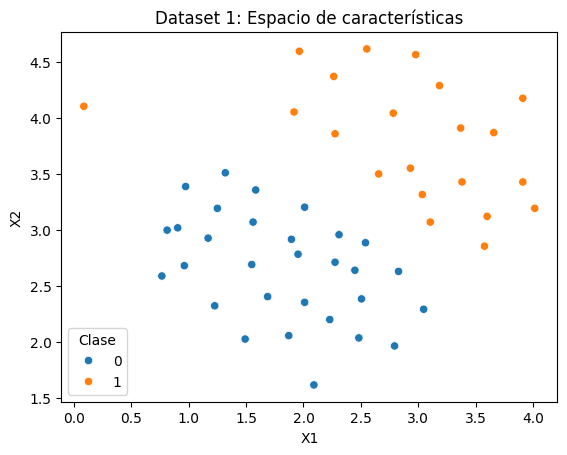

In [83]:
sns.scatterplot(data=X, x='X1', y='X2', hue='y')
plt.title('Dataset 1: Espacio de características')
plt.legend(title='Clase', loc='lower left');

Notice that there is one outlier positive example that sits apart from the others.  The classes are still linearly separable but it's a very tight fit.  We're going to train a linear support vector machine to learn the class boundary.

#### 5. LinearSVC
Declare a Linear SVC with the hyperparamenters:

```Python
LinearSVC(C=1, loss='hinge', max_iter=10000)
```

In [84]:
from sklearn.svm import LinearSVC

svm_c1 = LinearSVC(C=1, loss='hinge', max_iter=10000)

#### 6. Try the performance (score)
For the first experiment we'll use C=1 and see how it performs.

In [ ]:
# svm_c1.fit(X, y)

# print("Accuracy score", svm_c1.score(X, y))

Accuracy score 1.0


In [107]:
svm_c1.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number 

In [108]:
score_train_c1 = svm_c1.score(X_train, y_train)
score_test_c1 = svm_c1.score(X_test, y_test)

print(f"--- Modelo C=1 ---")
print(f"Accuracy Train: {score_train_c1:.4f}")
print(f"Accuracy Test:  {score_test_c1:.4f}")

--- Modelo C=1 ---
Accuracy Train: 1.0000
Accuracy Test:  1.0000


It appears that it mis-classified the outlier.

#### 7. Increase the value of C until you get a perfect classifier

In [109]:
svm_c_high = LinearSVC(C=1000, loss='hinge', max_iter=10000)
# svm_c_high.fit(X, y)

# print("Accuracy score", svm_c_high.score(X, y))

In [110]:
svm_c_high.fit(X_train, y_train)

score_train_high = svm_c_high.score(X_train, y_train)
score_test_high = svm_c_high.score(X_test, y_test)

print(f"\n--- Modelo C=1000 ---")
print(f"Accuracy Train: {score_train_high:.4f}")
print(f"Accuracy Test:  {score_test_high:.4f}")


--- Modelo C=1000 ---
Accuracy Train: 1.0000
Accuracy Test:  1.0000


This time we got a perfect classification of the training data, however by increasing the value of C we've created a decision boundary that is no longer a natural fit for the data.  We can visualize this by looking at the confidence level for each class prediction, which is a function of the point's distance from the hyperplane.

#### 8. Plot Decission Function
Get the `decision_function()` output for the first model. Plot a scatterplot with X1, X2 and a range of colors based on `decision_function()`

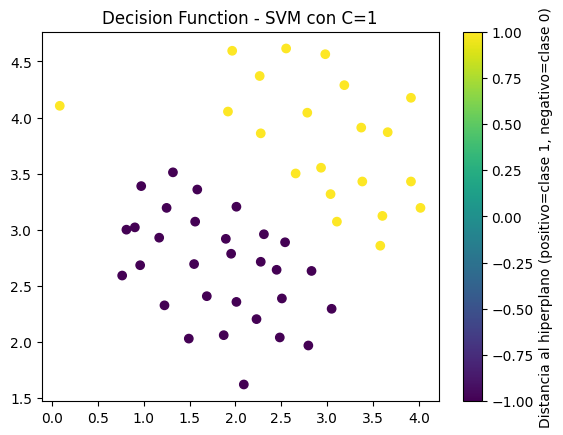

In [114]:
distances_c1 = svm_c1.decision_function(X)

sc = plt.scatter(X['X1'], X['X2'], c=distances_c1)
plt.colorbar(sc, label='Distancia al hiperplano (positivo=clase 1, negativo=clase 0)')
plt.title('Decision Function - SVM con C=1');

#### 9. Do the same with the second model

https://www.svm-tutorial.com/2015/06/svm-understanding-math-part-3/

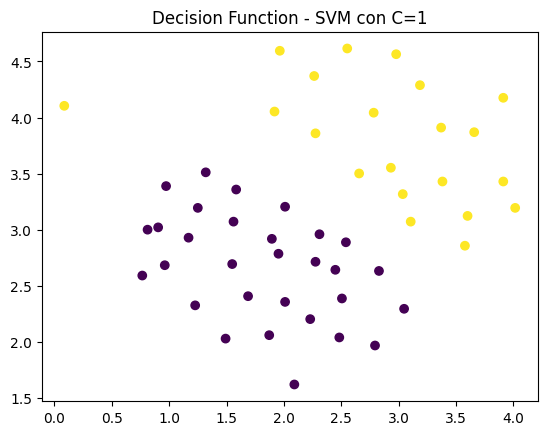

In [88]:
distances_c1 = svm_c_high.decision_function(X)

sc = plt.scatter(X['X1'], X['X2'], c=distances_c1)
plt.title('Decision Function - SVM con C=1');

#### 1. Load the data `ejer_1_data2.mat`

In [89]:
mat_file_2 = io.loadmat('data/ejer_1_data2.mat')
print(mat_file_2.keys())

dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])


#### 2. Create a DataFrame with the features and target

In [93]:
X2 = pd.DataFrame(mat_file_2['X'], columns=['X1', 'X2'])
y2 = mat_file_2['y'].ravel()

In [94]:
X2['y'] = y2

#### 3. Plot a scatterplot with the data

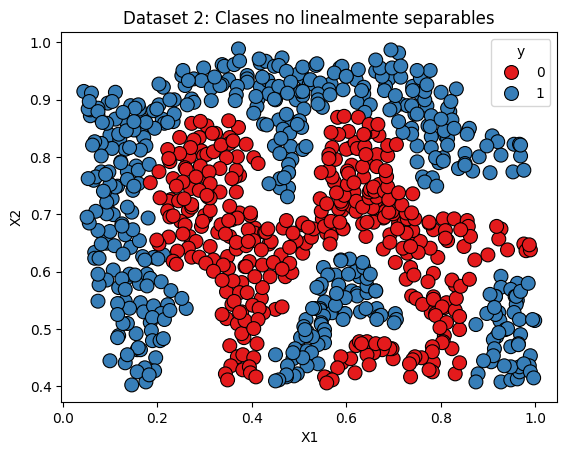

In [96]:
sns.scatterplot(data=X2, x='X1', y='X2', hue='y', palette='Set1', s=100, edgecolor='k')
plt.title('Dataset 2: Clases no linealmente separables');

For this data set we'll build a support vector machine classifier using the built-in RBF kernel and examine its accuracy on the training data.  To visualize the decision boundary, this time we'll shade the points based on the predicted probability that the instance has a negative class label.  We'll see from the result that it gets most of them right.

#### 4. Declare a SVC with this hyperparameters
```Python
SVC(C=100, gamma=10, probability=True)
```


In [97]:
from sklearn.svm import SVC
svm_rbf = SVC(C=100, gamma=10, probability=True)

#### 5. Fit the classifier and get the score

In [99]:
svm_rbf.fit(X2, y2)

print("Accuracy SVM RBF:", svm_rbf.score(X2, y2))

Accuracy SVM RBF: 1.0


#### 6. Plot the scatter plot and probability of predicting 0 with a [sequential color](https://matplotlib.org/3.1.1/tutorials/colors/colormaps.html)

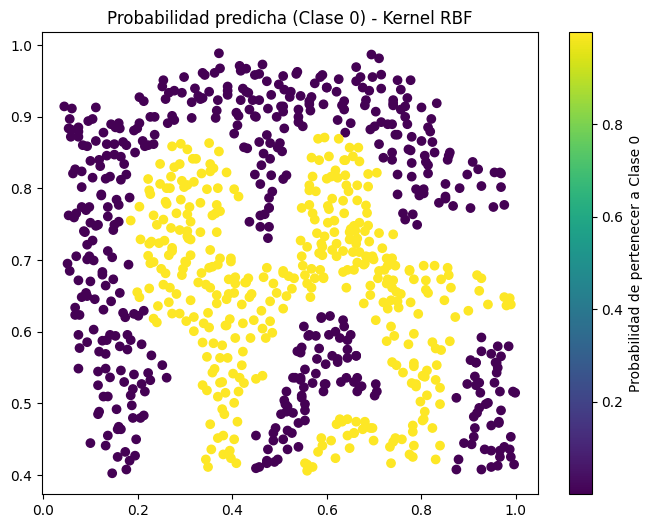

In [102]:
# predict_proba devuelve array de forma (n, 2). La columna 0 es P(clase=0)
prob_class_0 = svm_rbf.predict_proba(X2)[:, 0]

plt.figure(figsize=(8, 6))
# Usamos un colormap secuencial como 'viridis', 'YlOrRd' o 'plasma'
sc = plt.scatter(X2['X1'], X2['X2'], c=prob_class_0)
plt.colorbar(sc, label='Probabilidad de pertenecer a Clase 0')
plt.title('Probabilidad predicha (Clase 0) - Kernel RBF');